# How large an active space does each method actually need?

The formaldimine benchmark (see `results.ipynb`) settled on **CAS(2,2)** for the Berry phase and
**CAS(4,4)** for the state-averaged comparator. Those are small. This notebook asks whether
that is a property of the methods or just of an easy molecule, by running the same two
workflows over a ladder of active spaces on a harder system.

**System: ethylene**, at its twisted-pyramidalized S<sub>1</sub>/S<sub>0</sub> conical
intersection &mdash; the textbook case in nonadiabatic photochemistry. Two rigid coordinates:

| | |
|---|---|
| `tau` | torsion of one CH<sub>2</sub> about the C=C axis (deg) |
| `phi` | umbrella pyramidalization of that same CH<sub>2</sub> (deg) |

Both are rigid rotations, so every bond length and both HCH angles are preserved exactly.

**Everything except the active space is held fixed** &mdash; same basis, same geometry family,
and above all the *same loops*. Letting the loops move with the active space would mean each
CAS was being asked a different question.

Ladder: CAS(2,2), (4,4), (6,6), (8,8), (10,10), (12,12). The last spans the full valence space
&mdash; only the two carbon 1s orbitals stay frozen &mdash; and serves as the in-basis reference.

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

sys.path.insert(0, os.path.abspath(".."))
from berrycasscf.ethylene import CI_REGION, DEFAULT_BASIS
from berrycasscf.report import load_berry_records, berry_table, format_table
from berrycasscf.scan import ScanResult

ROOT = os.path.abspath("..")
ETH = os.path.join(ROOT, "results", "ethylene")

LADDER = [(2, 2), (4, 4), (6, 6), (8, 8), (10, 10), (12, 12)]
REFERENCE_CAS = (12, 12)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def load_scan(ne, ncas):
    # CAS(12,12) uses a thinner grid (see examples/run_active_space_study.py), so match on
    # the active space rather than a fixed grid shape.
    hits = sorted(glob.glob(os.path.join(ETH, f"ethylene_scan_cas{ne}-{ncas}_*.npz")))
    for p in hits:
        r = ScanResult.load(p)
        if np.isfinite(r.e_states).all():
            return r
    return None

def mirror_asymmetry(r):
    g = r.gap * 1000.0
    return float(np.nanmax(np.abs(g - g[::-1, :])))

scans = {cas: load_scan(*cas) for cas in LADDER}
available = [c for c, r in scans.items() if r is not None]
print("scans available:", ", ".join(f"CAS{c}" for c in available))

scans available: CAS(2, 2), CAS(4, 4), CAS(6, 6), CAS(8, 8), CAS(10, 10), CAS(12, 12)


## 1. A trap worth naming first: active-space drift

Before any result, a methodological point that nearly corrupted this study.

The gap scan warm-starts each grid point from its neighbour, purely for speed. For small active
spaces that is harmless. For larger ones it is not: the *active space itself* can drift along
the scan path, so the answer depends on the route taken to a geometry rather than on the
geometry.

Ethylene gives a clean way to catch this. Geometries at `tau` and `180 - tau` are exact mirror
images &mdash; verified by comparing their full interatomic-distance spectra &mdash; so a
correct gap map **must** be symmetric about `tau = 90`. Any asymmetry is drift, not physics.

With naive warm starting, CAS(8,8)/6-31G\* returned **19.1 mHa** and **29.4 mHa** at two
geometries that are mirror images of each other. A cold start at either gives **26.9 mHa**.

The fix (`ScanConfig.strategy = "best"`) runs both a warm and a cold start at every point and
keeps whichever reaches the lower state-averaged energy. The scans below are checked against
the mirror symmetry, and the residual asymmetry is reported for each.

In [2]:
ref = scans.get(REFERENCE_CAS)
ref_pt = ref.min_gap_point()[:2] if ref is not None else None

def gap_at(r, tau, phi):
    # gap this active space predicts at a given point, in mHa
    i = int(np.argmin(np.abs(r.alphas - tau)))
    j = int(np.argmin(np.abs(r.phis - phi)))
    return r.gap[i, j] * 1e3

def refined_phi(r):
    # Sub-grid intersection position along phi at tau = 90, by parabolic interpolation
    # through the grid minimum and its two neighbours. The grid step is 4 deg, so without
    # this the comparison between active spaces is quantised far too coarsely.
    i = int(np.argmin(np.abs(r.alphas - 90.0)))
    row = r.gap[i]
    j = int(np.nanargmin(row))
    if j == 0 or j == len(row) - 1:
        return float(r.phis[j])
    y0, y1, y2 = row[j - 1], row[j], row[j + 1]
    denom = y0 - 2 * y1 + y2
    if abs(denom) < 1e-18:
        return float(r.phis[j])
    step = float(r.phis[1] - r.phis[0])
    return float(r.phis[j] + 0.5 * (y0 - y2) / denom * step)

ref_phi = refined_phi(ref) if ref is not None else None

print(f"{'active space':>13} {'own min (mHa)':>13} {'phi (refined)':>13} "
      f"{'err vs ref':>11} {'gap at ref CI':>14} {'mirror asym':>13}")
print("-" * 83)
for cas in LADDER:
    r = scans.get(cas)
    if r is None:
        print(f"{'CAS%s' % (cas,):>13} {'(not run)':>13}")
        continue
    t, p, g = r.min_gap_point()
    rp = refined_phi(r)
    err = "  -" if ref_phi is None else f"{rp - ref_phi:+10.2f}d"
    atref = "  -" if ref_pt is None else f"{gap_at(r, *ref_pt):14.3f}"
    print(f"{'CAS%s' % (cas,):>13} {g*1e3:13.3f} {rp:13.2f} {err} {atref} "
          f"{mirror_asymmetry(r):13.2e}")
print("\nMirror asymmetry at the 1e-3 mHa level or below means the scan is path-independent.")
print("Grid spacing is 4 deg, so a position error of 4 deg is one grid step.")
print("'gap at ref CI' is the sharper measure: what each active space thinks the gap is at the")
print("position the reference puts the intersection. A large value there means that active")
print("space does not see an intersection where there is one.")

 active space own min (mHa) phi (refined)  err vs ref  gap at ref CI   mirror asym
-----------------------------------------------------------------------------------
    CAS(2, 2)         0.175        110.02      +0.02d          0.175      2.84e-11
    CAS(4, 4)         1.362        114.85      +4.85d          6.758      1.13e-07
    CAS(6, 6)         0.155        102.09      -7.91d         11.305      2.77e-05
    CAS(8, 8)         2.033        103.11      -6.90d          9.250      1.07e-06
  CAS(10, 10)         1.850        109.10      -0.90d          1.850      3.45e-09
  CAS(12, 12)         0.189        110.00      +0.00d          0.189      4.26e-11

Mirror asymmetry at the 1e-3 mHa level or below means the scan is path-independent.
Grid spacing is 4 deg, so a position error of 4 deg is one grid step.
'gap at ref CI' is the sharper measure: what each active space thinks the gap is at the
position the reference puts the intersection. A large value there means that active
space do

## 2. Where each active space puts the intersection

CAS(12,12) costs about 45 s per grid point, so the reference is run on a thinner
3&times;11 grid rather than the 11&times;11 used for the other rungs. That still does both jobs it
has to: it contains the `tau = 90` line, where the intersection sits and from which the
reference position is measured, and it contains one exact mirror pair
(`tau` = 70 and 110) for the path-independence check. Its panel below is correspondingly
narrow.

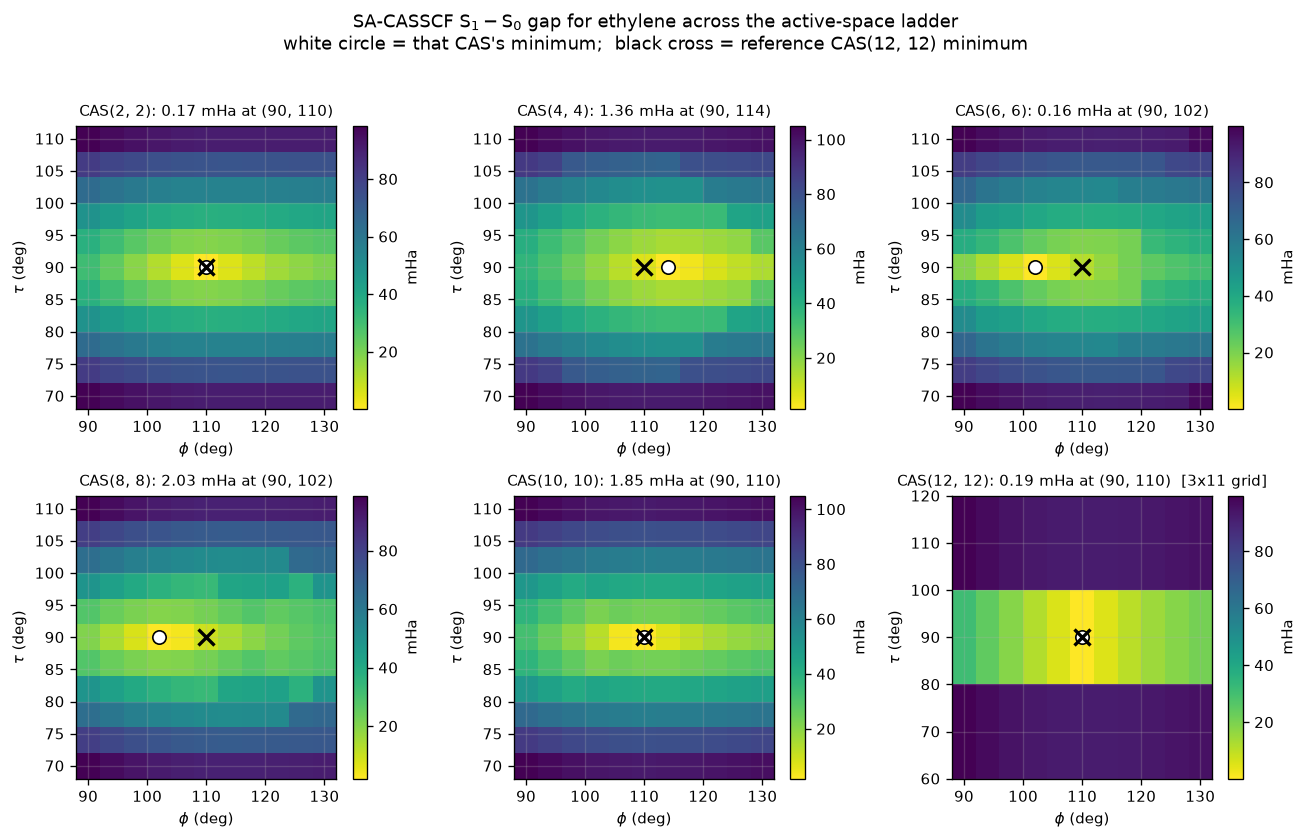

In [3]:
avail = [c for c in LADDER if scans.get(c) is not None]
ncol = 3
nrow = int(np.ceil(len(avail) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(11, 3.4 * nrow), squeeze=False)
ref = scans.get(REFERENCE_CAS)
ref_pt = ref.min_gap_point()[:2] if ref is not None else None

for k, cas in enumerate(avail):
    ax = axes[k // ncol][k % ncol]
    r = scans[cas]
    T, P = np.meshgrid(r.alphas, r.phis, indexing="ij")
    pcm = ax.pcolormesh(P, T, r.gap * 1e3, shading="nearest", cmap="viridis_r")
    fig.colorbar(pcm, ax=ax, label="mHa")
    t, p, g = r.min_gap_point()
    ax.plot(p, t, "wo", ms=8, mec="k", zorder=6)
    if ref_pt is not None:
        ax.plot(ref_pt[1], ref_pt[0], "kx", ms=10, mew=2, zorder=7)
    ax.set_title(f"CAS{cas}: {g*1e3:.2f} mHa at ({t:.0f}, {p:.0f})"
                 + ("  [3x11 grid]" if r.alphas.size < 11 else ""), fontsize=9)
    ax.set_xlabel(r"$\phi$ (deg)"); ax.set_ylabel(r"$\tau$ (deg)")
for k in range(len(avail), nrow * ncol):
    axes[k // ncol][k % ncol].set_visible(False)
fig.suptitle("SA-CASSCF S$_1-$S$_0$ gap for ethylene across the active-space ladder\n"
             "white circle = that CAS's minimum;  black cross = reference CAS%s minimum"
             % (REFERENCE_CAS,), y=1.02)
plt.tight_layout(); plt.show()

## 3. The gap through the intersection

A cut along `tau = 90` shows whether each active space produces a genuine cone (linear in the
coordinate, closing to zero) or merely a shallow avoided crossing.

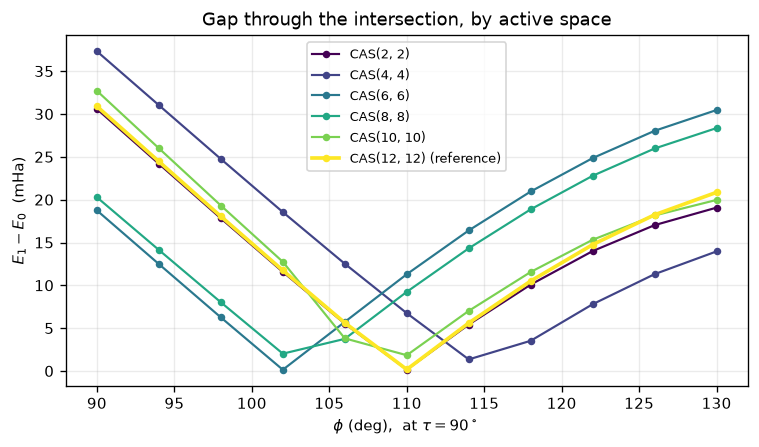

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
cmap = plt.get_cmap("viridis")
for k, cas in enumerate(avail):
    r = scans[cas]
    i = int(np.argmin(np.abs(r.alphas - 90.0)))
    ax.plot(r.phis, r.gap[i] * 1e3, "o-", ms=3.5,
            color=cmap(k / max(len(avail) - 1, 1)),
            lw=2.2 if cas == REFERENCE_CAS else 1.3,
            label=f"CAS{cas}" + (" (reference)" if cas == REFERENCE_CAS else ""))
ax.set_xlabel(r"$\phi$ (deg),  at $\tau = 90^\circ$")
ax.set_ylabel(r"$E_1 - E_0$  (mHa)")
ax.set_title("Gap through the intersection, by active space")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Berry phase across the same ladder

The loops are **fixed** for every active space, centred on the intersection located by the
reference CAS. `E_x` encloses it; `E_1` and `E_2` are displaced along `tau` and enclose nothing.
Each is run at two discretizations, so the stability criterion from the formaldimine study
(same phase at every `N`, every run `OK`) applies unchanged.

In [5]:
records = load_berry_records(ETH)
rows = berry_table(records)
if rows:
    print(format_table(rows, ["loop", "CAS", "N", "product", "endpoint",
                              "min|ovl|", "phase", "status"]))
else:
    print("No Berry records yet. Run: python examples/run_active_space_study.py berry")

loop  CAS         N   product  endpoint  min|ovl|  phase             status
----  ----------  --  -------  --------  --------  ----------------  ------
E_1   CAS(10,10)  13  +0.8964  +1.0000   +0.9864   trivial (0)       OK    
E_1   CAS(10,10)  21  +0.9334  +1.0000   +0.9947   trivial (0)       OK    
E_1   CAS(12,12)  13  +0.8935  +1.0000   +0.9861   trivial (0)       OK    
E_1   CAS(12,12)  21  +0.9315  +1.0000   +0.9946   trivial (0)       OK    
E_1   CAS(2,2)    13  +0.8972  +1.0000   +0.9865   trivial (0)       OK    
E_1   CAS(2,2)    21  +0.9339  +1.0000   +0.9947   trivial (0)       OK    
E_1   CAS(4,4)    13  +0.8993  +1.0000   +0.9869   trivial (0)       OK    
E_1   CAS(4,4)    21  +0.9353  +1.0000   +0.9949   trivial (0)       OK    
E_1   CAS(6,6)    13  +0.8962  +1.0000   +0.9865   trivial (0)       OK    
E_1   CAS(6,6)    21  +0.9333  +1.0000   +0.9947   trivial (0)       OK    
E_1   CAS(8,8)    13  +0.8962  +1.0000   +0.9865   trivial (0)       OK    
E_1   CAS(8,

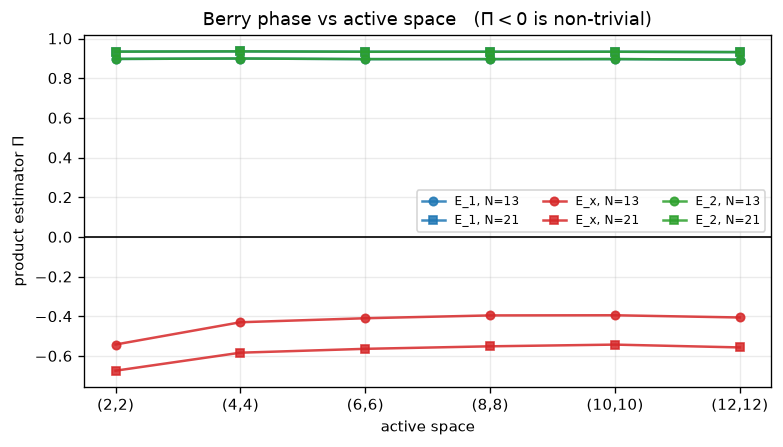

In [6]:
if rows:
    fig, ax = plt.subplots(figsize=(6.6, 3.8))
    colour = {"E_1": "tab:blue", "E_x": "tab:red", "E_2": "tab:green"}
    order = [f"CAS({n},{m})" for n, m in LADDER]
    xs = np.arange(len(order))
    for loop in ["E_1", "E_x", "E_2"]:
        for n, mk in [(13, "o"), (21, "s")]:
            y, x = [], []
            for k, cl in enumerate(order):
                hit = [r for r in rows if r["loop"] == loop and r["CAS"] == cl and r["N"] == n]
                if hit:
                    y.append(hit[0]["product"]); x.append(k)
            if y:
                ax.plot(x, y, mk + "-", color=colour[loop], ms=5, alpha=0.85,
                        label=f"{loop}, N={n}")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(xs); ax.set_xticklabels([o.replace("CAS", "") for o in order])
    ax.set_xlabel("active space"); ax.set_ylabel(r"product estimator $\Pi$")
    ax.set_title(r"Berry phase vs active space   ($\Pi<0$ is non-trivial)")
    ax.legend(fontsize=7, ncol=3); plt.tight_layout(); plt.show()

### A free consistency check

The two control loops are mirror images of each other: `E_1` is centred at
`tau = 90 - 30` and `E_2` at `tau = 90 + 30`, and the geometries at `tau` and `180 - tau` are
exactly isometric. So **every** quantity computed on `E_1` must equal its counterpart on `E_2`,
digit for digit. Nothing in the continuation knows this &mdash; the two loops are traversed
independently, through different geometries, with independently converged orbitals and
independently chosen CI signs. Agreement is therefore a genuine end-to-end test of the whole
pipeline on a molecule it was not developed on.

In [7]:
if rows:
    print(f"{'CAS':>10}  {'N':>3}   {'Pi(E_1)':>10}  {'Pi(E_2)':>10}   {'|difference|':>12}")
    print("-" * 56)
    worst = 0.0
    for cas in LADDER:
        cl = f"CAS({cas[0]},{cas[1]})"
        for n in sorted({r["N"] for r in rows}):
            a = [r for r in rows if r["CAS"] == cl and r["loop"] == "E_1" and r["N"] == n]
            b = [r for r in rows if r["CAS"] == cl and r["loop"] == "E_2" and r["N"] == n]
            if not (a and b):
                continue
            d = abs(a[0]["product"] - b[0]["product"])
            worst = max(worst, d)
            print(f"{cl:>10}  {n:>3}   {a[0]['product']:>10.6f}  {b[0]['product']:>10.6f}"
                  f"   {d:>12.2e}")
    print(f"\nlargest mirror discrepancy across the ladder: {worst:.2e}")

       CAS    N      Pi(E_1)     Pi(E_2)   |difference|
--------------------------------------------------------
  CAS(2,2)   13     0.897162    0.897163       1.08e-06
  CAS(2,2)   21     0.933913    0.933913       1.37e-07
  CAS(4,4)   13     0.899261    0.899261       1.96e-07
  CAS(4,4)   21     0.935286    0.935286       1.47e-07
  CAS(6,6)   13     0.896221    0.896221       6.94e-08
  CAS(6,6)   21     0.933306    0.933306       2.41e-07
  CAS(8,8)   13     0.896228    0.896227       2.90e-07
  CAS(8,8)   21     0.933312    0.933312       1.25e-07
CAS(10,10)   13     0.896379    0.896381       1.57e-06
CAS(10,10)   21     0.933417    0.933418       8.58e-07
CAS(12,12)   13     0.893501    0.893503       1.99e-06
CAS(12,12)   21     0.931544    0.931545       1.40e-06

largest mirror discrepancy across the ladder: 1.99e-06


## 5. Discretization: bigger active spaces need finer loops

Before the verdict, one effect that would otherwise be mistaken for an active-space failure.

The continuity criterion requires every adjacent overlap around the loop to stay above 0.80.
How fast the wavefunction turns as the loop is traversed is itself active-space dependent: a
larger CAS has more room to rearrange, so the same loop at the same `N` produces smaller
adjacent overlaps. Below the threshold the run is reported as FAILED &mdash; correctly, because
the discretization is too coarse to establish continuity &mdash; and refining `N` fixes it.

This is a statement about the **loop discretization**, not about whether the active space can
describe the physics, and the two must not be conflated.

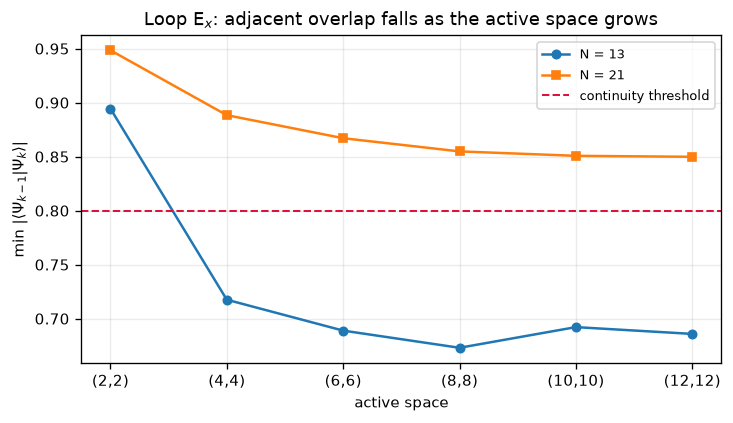

In [8]:
if rows:
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    order = [f"CAS({n},{m})" for n, m in LADDER]
    for n, mk in [(13, "o"), (21, "s"), (31, "^")]:
        xs, ys = [], []
        for k, cl in enumerate(order):
            hit = [r for r in rows if r["loop"] == "E_x" and r["CAS"] == cl and r["N"] == n]
            if hit:
                xs.append(k); ys.append(hit[0]["min|ovl|"])
        if xs:
            ax.plot(xs, ys, mk + "-", ms=5, label=f"N = {n}")
    ax.axhline(0.80, color="crimson", ls="--", lw=1.2, label="continuity threshold")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([o.replace("CAS", "") for o in order])
    ax.set_xlabel("active space"); ax.set_ylabel(r"min $|\langle\Psi_{k-1}|\Psi_k\rangle|$")
    ax.set_title("Loop E$_x$: adjacent overlap falls as the active space grows")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Verdict: the smallest active space each method needs

Two separate questions, judged with the criteria used throughout this project.

The controls sit outside the scanned region, so they were checked separately: sampling the
SA-CASSCF(2,2) gap on and inside each (centre plus rings of 8 points at radius 6&deg; and
12&deg;) gives a minimum of **81.8 mHa** for both, against **0.177 mHa** at the intersection.
Nothing is enclosed.

**Berry phase.** For each active space, the smallest `N` at which the run passes every check
(all points converged, continuity held, endpoint returned to the same state, both estimators
agreeing), and whether the phase is then correct on all three loops: non-trivial on `E_x`,
trivial on `E_1` and `E_2`.

**SA comparator.** The active space must (a) put its gap minimum inside `E_x`, (b) place it
close to the reference active space's minimum, (c) drive the gap low enough to read as an
intersection, and (d) produce a mirror-symmetric map &mdash; a map that fails the symmetry test
is path-dependent and not trustworthy whatever number it reports.

In [9]:
WANT = {"E_x": "non-trivial (pi)", "E_1": "trivial (0)", "E_2": "trivial (0)"}
TOL_DEG = 2.0          # half a grid step: what counts as "the same position"

def berry_verdict(cas):
    # Smallest N at which all three loops pass every check with the right phase.
    # None  -> rung not run, or not run completely (a missing record must never be
    #          mistaken for a failure); False -> every complete N failed.
    cl = f"CAS({cas[0]},{cas[1]})"
    sub = [r for r in rows if r["CAS"] == cl]
    complete_n = [n for n in sorted({r["N"] for r in sub})
                  if {r["loop"] for r in sub if r["N"] == n} == set(WANT)]
    if not complete_n:
        return None
    for n in complete_n:
        at_n = [r for r in sub if r["N"] == n]
        if all(r["status"] == "OK" for r in at_n) and all(
            r["phase"] == WANT[r["loop"]] for r in at_n
        ):
            return n
    return False

positions = {c: refined_phi(scans[c]) for c in LADDER if scans.get(c) is not None}
ref_phi = positions.get(REFERENCE_CAS)

print(f"{'active space':>13} {'Berry: min N':>13} | {'phi':>8} {'err vs ref':>11} "
      f"{'accurate':>9} {'stable':>8}")
print("-" * 72)
for k, cas in enumerate(LADDER):
    b = berry_verdict(cas)
    btxt = "n/a" if b is None else (f"N = {b}" if b else "fails at all N")
    if cas not in positions:
        print(f"{'CAS%s' % (cas,):>13} {btxt:>13} | {'(scan pending)':>8}")
        continue
    phi = positions[cas]
    if ref_phi is None:
        err_txt, acc_txt = f"{'-':>11}", f"{'-':>9}"
    else:
        err = phi - ref_phi
        err_txt = f"{err:+11.2f}"
        acc_txt = f"{('yes' if abs(err) <= TOL_DEG else 'NO'):>9}"
    # "stable" = every LARGER active space tested agrees with this one, i.e. enlarging the
    # space does not move the answer. This is the test a practitioner can actually apply,
    # because it needs no reference.
    larger = [positions[c] for c in LADDER[k + 1:] if c in positions]
    # The largest rung has nothing above it to be checked against, so it is not "unstable".
    stab_txt = "-" if not larger else ("yes" if all(abs(phi - q) <= TOL_DEG for q in larger)
                                       else "NO")
    print(f"{'CAS%s' % (cas,):>13} {btxt:>13} | {phi:8.2f} {err_txt} "
          f"{acc_txt} {stab_txt:>8}")

acc = [c for c in LADDER if c in positions and ref_phi is not None
       and abs(positions[c] - ref_phi) <= TOL_DEG]
stab = [c for k, c in enumerate(LADDER)
        if c in positions
        and [positions[q] for q in LADDER[k + 1:] if q in positions]
        and all(abs(positions[c] - positions[q]) <= TOL_DEG
                for q in LADDER[k + 1:] if q in positions)]
okb = [c for c in LADDER if berry_verdict(c)]
print()
print(f"Berry phase correct from:                      "
      f"{min(okb) if okb else 'none of those tested'}")
print(f"SA comparator accurate from (vs reference):    "
      f"{min(acc) if acc else 'none of those tested'}")
print(f"SA comparator STABLE from (no reference used): "
      f"{min(stab) if stab else 'none of those tested'}")

 active space  Berry: min N |      phi  err vs ref  accurate   stable
------------------------------------------------------------------------
    CAS(2, 2)        N = 13 |   110.02       +0.02       yes       NO
    CAS(4, 4)        N = 21 |   114.85       +4.85        NO       NO
    CAS(6, 6)        N = 21 |   102.09       -7.91        NO       NO
    CAS(8, 8)        N = 21 |   103.11       -6.90        NO       NO
  CAS(10, 10)        N = 21 |   109.10       -0.90       yes      yes
  CAS(12, 12)        N = 21 |   110.00       +0.00       yes        -

Berry phase correct from:                      (2, 2)
SA comparator accurate from (vs reference):    (2, 2)
SA comparator STABLE from (no reference used): (10, 10)


The last two lines are the point of the whole study, and they disagree.

*Accurate* asks whether an active space happens to land on the right answer. *Stable* asks the
question a practitioner can actually ask without already knowing the answer: **does enlarging the
active space leave the result unchanged?** For ethylene, CAS(2,2) is accurate to 0.01&deg; but
not stable &mdash; the very next rung moves the intersection by nearly 5&deg;, and the one after
that by 8&deg; the other way. Nothing available at CAS(2,2) would tell you it was right.

So the honest requirement here is set by stability, not by the smallest space that works.

## 7. Conclusions

*Filled in from the numbers above once the full ladder has run &mdash; see
`docs/active_space.md` for the written-up version.*